In [ ]:
!pip install opencv-python numpy matplotlib plotly pandas IPython


Processing video: 01_task1.mp4


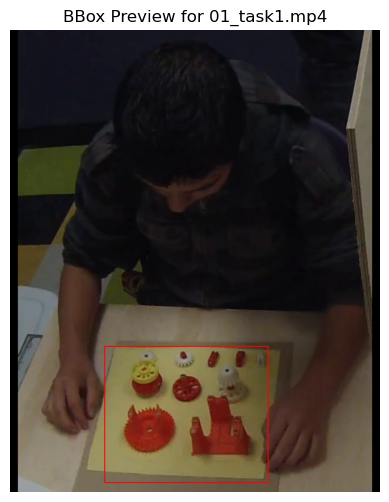


Processing video: 02_task1.mp4


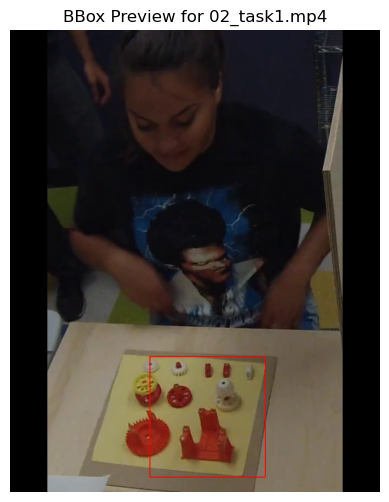

Skipping this video as user did not confirm bounding box.

Processing video: 03_task1.mp4


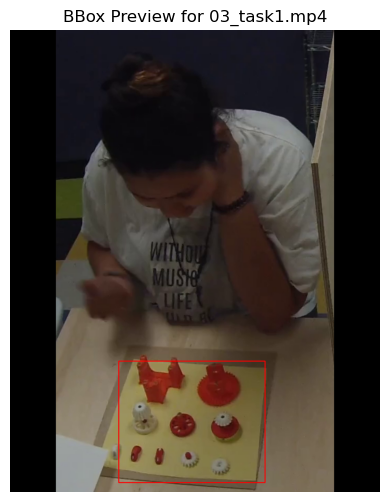

Skipping this video as user did not confirm bounding box.

Processing video: 05_task1.mp4


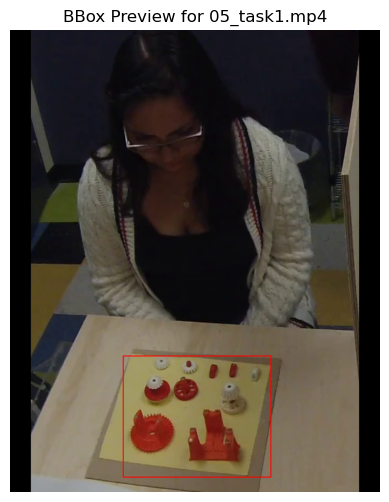

Skipping this video as user did not confirm bounding box.

Processing video: 06_task1.mp4


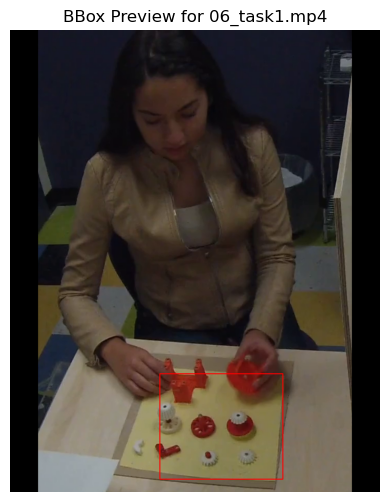

Skipping this video as user did not confirm bounding box.

Processing video: 09_task1.mp4


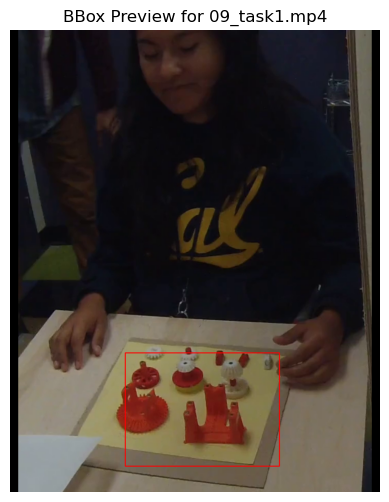

Skipping this video as user did not confirm bounding box.

Processing video: 100_gearbox.mp4


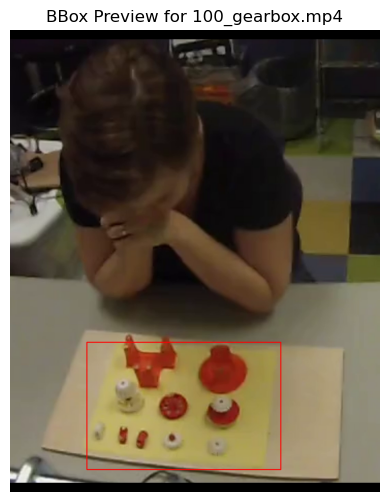


Processing video: 101_gearbox.mp4


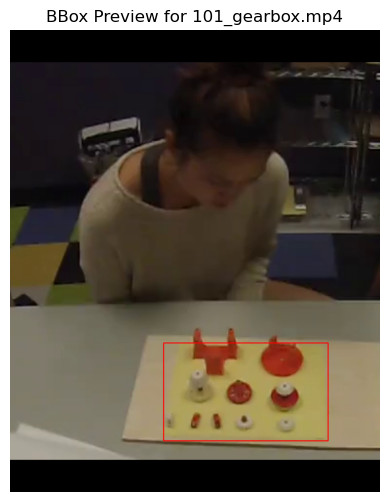


Processing video: 102_gearbox.mp4


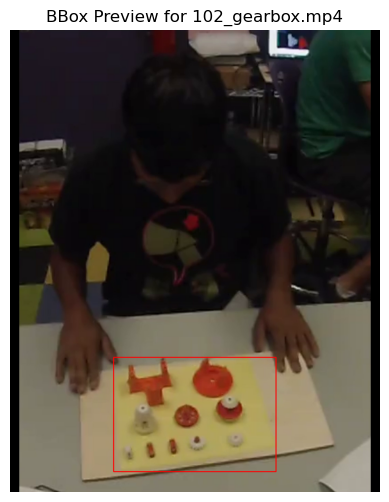

Skipping this video as user did not confirm bounding box.

Processing video: 103_gearbox.mp4


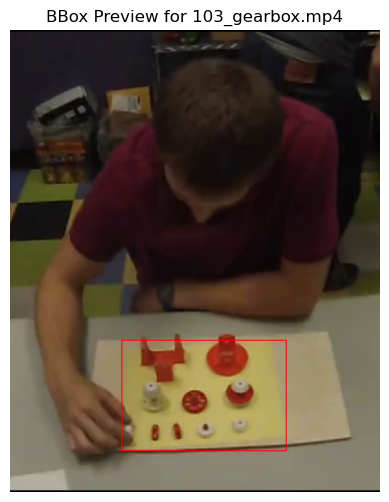

Skipping this video as user did not confirm bounding box.

Processing video: 104_gearbox.mp4


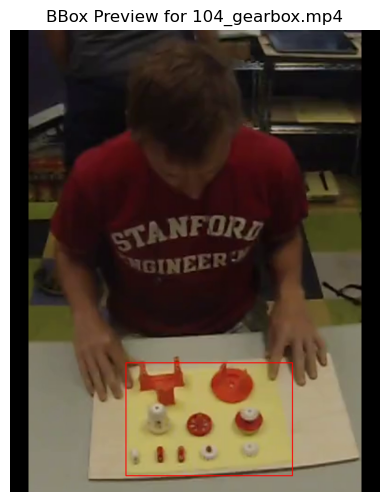


Processing video: 105_gearbox.mp4


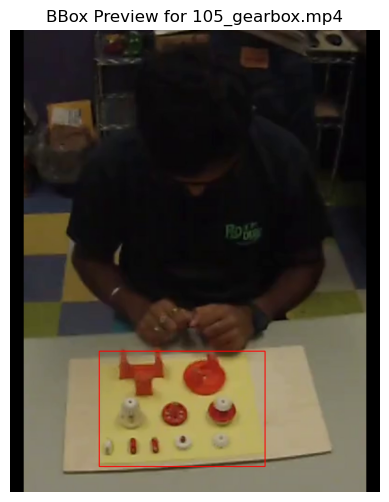


Processing video: 107_gearbox.mp4


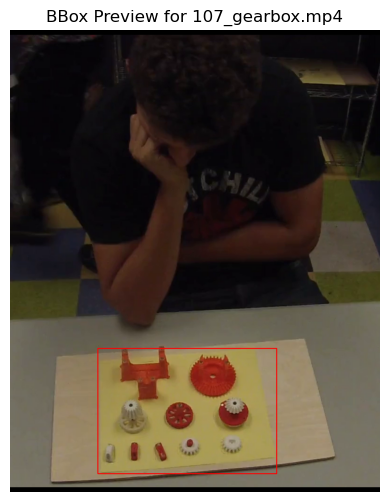


Processing video: 108_gearbox.mp4


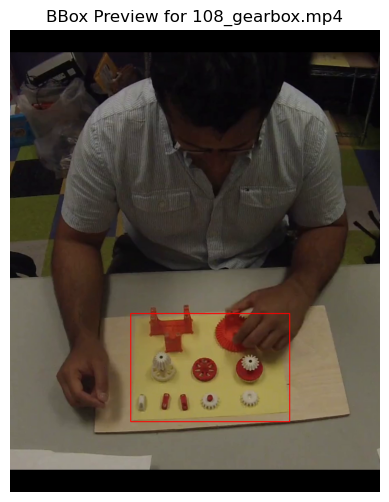


Processing video: 10_task1.mp4


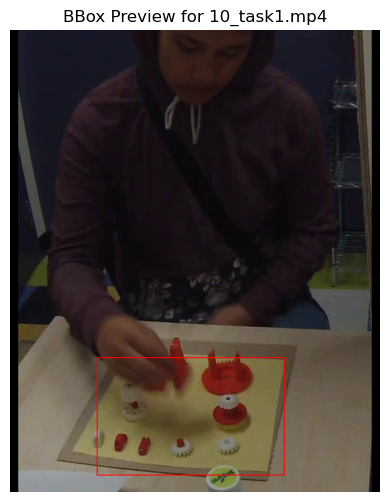

Skipping this video as user did not confirm bounding box.

Processing video: 110_gearbox.mp4


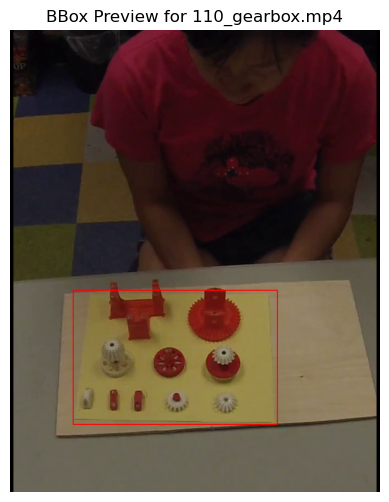


Processing video: 11_task1.mp4


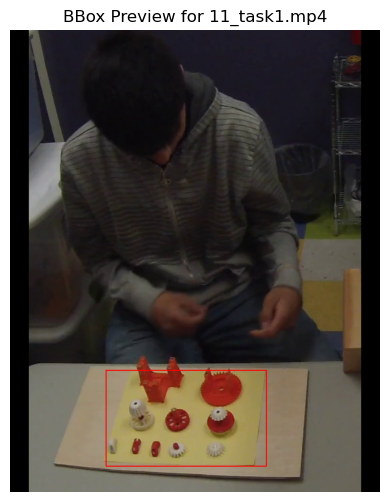


Processing video: 12_task1.mp4


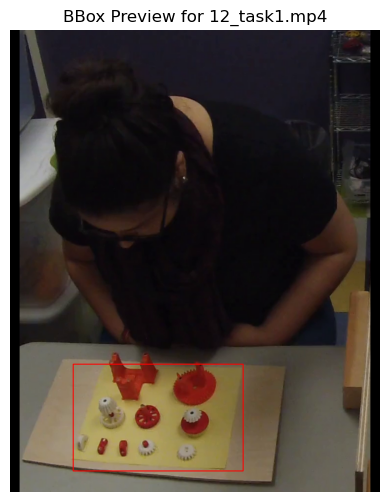


Processing video: 13_task1.mp4


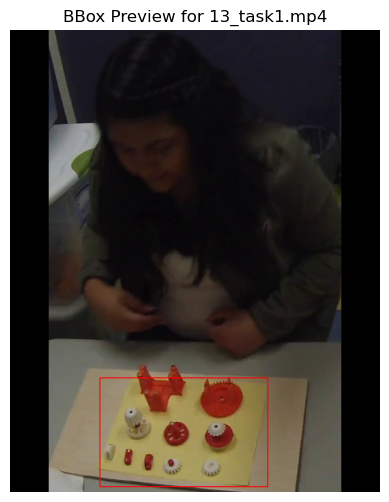

Skipping this video as user did not confirm bounding box.

Processing video: 14_task1.mp4


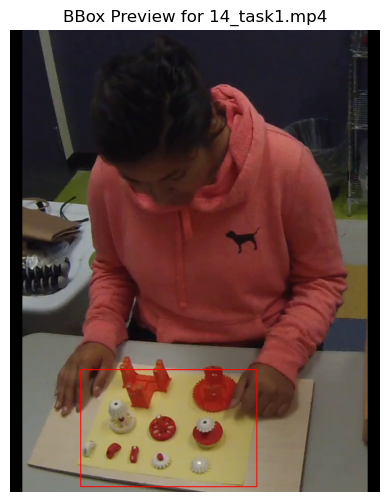

Skipping this video as user did not confirm bounding box.

Processing video: 15_task1.mp4


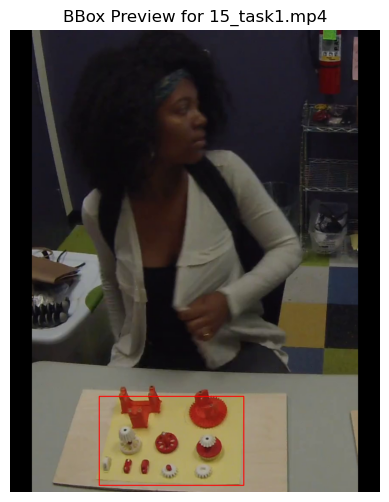


Processing video: 16_task1.mp4


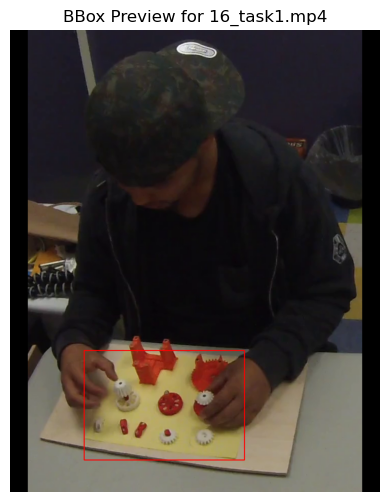

Skipping this video as user did not confirm bounding box.

Processing video: 17_task1.mp4


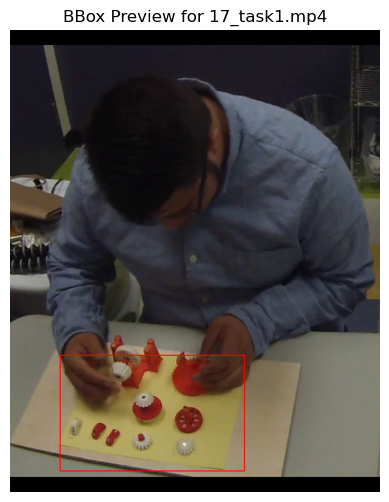

Skipping this video as user did not confirm bounding box.

Processing video: 20_task1.mp4


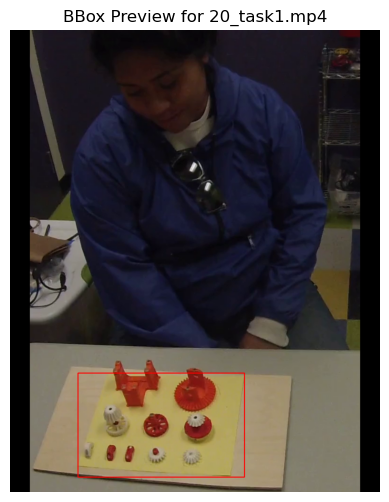

Skipping this video as user did not confirm bounding box.

Scale results saved to: Video_Paper_Scale_Experts.csv


,video_filename,paper_length_px,scale_inch_per_px
0,01_task1.mp4,477.0,0.023061
1,02_task1.mp4,NaN,NaN
2,03_task1.mp4,NaN,NaN
3,05_task1.mp4,NaN,NaN
4,06_task1.mp4,NaN,NaN
5,09_task1.mp4,NaN,NaN
6,100_gearbox.mp4,566.0,0.019435
7,101_gearbox.mp4,480.0,0.022917
8,102_gearbox.mp4,NaN,NaN
9,103_gearbox.mp4,NaN,NaN


Interactive scale plot saved to 'paper_scale_plot.html'.


In [2]:
#!/usr/bin/env python
# coding: utf-8

import os
import cv2
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------

# Directory containing your videos
VIDEO_DIR = "Davis_Data_Processed_16Jan25"

# Output CSV file
OUTPUT_CSV = "Video_Paper_Scale_Experts.csv"

# Real-world dimension to map to (inches)
REAL_PAPER_LENGTH_INCHES = 11.0

# Color threshold parameters (HSV) for yellow detection
# You'll need to tune these to match your video conditions.
YELLOW_LOWER = (20, 100, 100)   # Lower bound of HSV for "yellow"
YELLOW_UPPER = (40, 255, 255)   # Upper bound of HSV for "yellow"

# Minimum area threshold (in pixels) to filter out small noise
MIN_AREA = 500

# -----------------------------------------------------------------------------
# Helper Function: Extract First Frame of a Video
# -----------------------------------------------------------------------------
def get_first_frame(video_path):
    """Return the first frame of the given video as a BGR numpy array."""
    cap = cv2.VideoCapture(video_path)
    success, frame = cap.read()
    cap.release()
    if not success:
        raise ValueError(f"Could not read first frame from {video_path}")
    return frame

# -----------------------------------------------------------------------------
# Helper Function: Detect Yellow Paper
# -----------------------------------------------------------------------------
def detect_yellow_paper(frame_bgr):
    """
    Detect the largest bounding box in the frame that meets a certain yellow
    color threshold in HSV. Returns (x, y, w, h) of the bounding box or None if not found.
    """
    # Convert from BGR to HSV
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    # Threshold for yellow color
    mask = cv2.inRange(frame_hsv, YELLOW_LOWER, YELLOW_UPPER)

    # Optional: morphological operations to reduce noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Find the largest contour by area
    max_contour = None
    max_area = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > max_area:
            max_area = area
            max_contour = cnt

    if max_contour is None or max_area < MIN_AREA:
        return None

    # Get bounding box of the largest contour
    x, y, w, h = cv2.boundingRect(max_contour)
    return (x, y, w, h)

# -----------------------------------------------------------------------------
# Main Processing Loop
# -----------------------------------------------------------------------------
def generate_paper_scales(video_dir=VIDEO_DIR, output_csv=OUTPUT_CSV):
    """
    For each video in `video_dir`, detect the bounding box of the yellow paper 
    in the first frame, confirm with user, and map the largest dimension of that
    bounding box to 11" to generate a scale. Output results to a CSV.
    """
    results = []
    
    # List all files in VIDEO_DIR (filter for typical video extensions)
    valid_extensions = (".mp4", ".mov", ".avi", ".mkv")
    video_files = [f for f in os.listdir(video_dir) if f.lower().endswith(valid_extensions)]
    video_files.sort()  # optional sorting

    for vid_name in video_files:
        video_path = os.path.join(video_dir, vid_name)
        
        print(f"\nProcessing video: {vid_name}")
        
        # 1. Read the first frame
        frame = get_first_frame(video_path)

        # 2. Detect bounding box for the yellow paper
        bbox = detect_yellow_paper(frame)
        if bbox is None:
            print("Warning: Could not detect yellow paper in this video.")
            # Append a row indicating no detection
            results.append({
                "video_filename": vid_name,
                "paper_length_px": None,
                "scale_inch_per_px": None
            })
            continue

        x, y, w, h = bbox
        
        # 3. Draw bounding box on a copy of the frame for preview
        preview_frame = frame.copy()
        cv2.rectangle(preview_frame, (x, y), (x + w, y + h), (0, 0, 255), 2)

        # Convert the preview_frame to RGB for inline display with matplotlib
        preview_rgb = cv2.cvtColor(preview_frame, cv2.COLOR_BGR2RGB)
        
        # Show the frame with bounding box inline (not interactive) to confirm
        plt.figure(figsize=(8, 6))
        plt.title(f"BBox Preview for {vid_name}")
        plt.imshow(preview_rgb)
        plt.axis('off')
        plt.show()

        # 4. Manual confirmation in Jupyter (blocking input)
        user_input = input("Confirm bounding box? (y/n): ").strip().lower()
        if user_input != 'y':
            print("Skipping this video as user did not confirm bounding box.")
            results.append({
                "video_filename": vid_name,
                "paper_length_px": None,
                "scale_inch_per_px": None
            })
            continue
        
        # 5. Get the dimension that we consider the "length"
        #    We'll assume the longest side of the bounding box is the "paper length"
        paper_length_px = max(w, h)
        
        # 6. Map that length to 11 inches => scale factor
        #    scale_inch_per_px = 11 / paper_length_px
        scale_inch_per_px = REAL_PAPER_LENGTH_INCHES / paper_length_px

        # 7. Store the results
        results.append({
            "video_filename": vid_name,
            "paper_length_px": paper_length_px,
            "scale_inch_per_px": scale_inch_per_px
        })

    # -----------------------------------------------------------------------------
    # Create a DataFrame and Save to CSV
    # -----------------------------------------------------------------------------
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nScale results saved to: {output_csv}")

    return df

# -----------------------------------------------------------------------------
# Run the main function
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    df_scales = generate_paper_scales()
    display(df_scales)

    # Optional: quick Plotly chart of scale_inch_per_px across videos
    fig = px.bar(
        df_scales.dropna(), 
        x="video_filename", 
        y="scale_inch_per_px", 
        title="Paper Scale (inch/px) per Video",
        labels={"video_filename": "Video File", "scale_inch_per_px": "Scale (inch/px)"}
    )
    fig.show()

    # You can also save this Plotly figure as an interactive HTML:
    fig.write_html("paper_scale_plot.html")
    print("Interactive scale plot saved to 'paper_scale_plot.html'.")
